In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None) # show every column
pd.options.display.float_format = "{:,.0f}".format # 1234567.0 -> 1,234,567

In [8]:
rng = np.random.default_rng(42)  # fixed seed: everyone gets the same data

cities = ["Seoul", "Busan", "Incheon", "Daegu", "Daejeon", "Gwangju"]
customers = pd.DataFrame({
    "customer_id": range(1001, 1061),
    "customer_name": [f"Customer_{i}" for i in range(1, 61)],
    "city": rng.choice(cities, 60, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]),
    "segment": rng.choice(["Regular", "Premium"], 60, p=[0.75, 0.25]),
})

catalog = {
    "Electronics": [("Wireless Earbuds", 59000), ("Phone Charger", 25000),
                    ("Smart Watch", 189000)],
    "Home & Kitchen": [("Air Fryer", 99000), ("Rice Cooker", 129000),
                       ("Water Bottle", 18000)],
    "Fashion": [("Running Shoes", 89000), ("Winter Jacket", 159000),
                ("Backpack", 49000)],
    "Beauty": [("Sunscreen", 22000), ("Face Serum", 45000), ("Hand Cream", 12000)],
}

n = 300
rows = []
for i in range(n):
    cat = rng.choice(list(catalog))
    prod, price = catalog[cat][rng.integers(0, 3)]
    day = pd.Timestamp("2026-03-01") + pd.Timedelta(days=int(rng.integers(0, 180)))
    rows.append({
        "order_id": 5001 + i,
        "customer_id": int(rng.choice(customers["customer_id"].iloc[:50])),
        "order_date": day.strftime("%Y-%m-%d"),
        "category": cat,
        "product": prod,
        "unit_price": f"\u20a9{price:,}",
        "quantity": float(rng.integers(1, 5)),
        "payment_method": rng.choice(["Card", "KakaoPay", "Bank Transfer"]),
    })

orders = pd.DataFrame(rows)

# ---- make the data realistically messy ----
orders.loc[rng.choice(n, 15, replace=False), "quantity"] = np.nan
orders.loc[rng.choice(n, 20, replace=False), "payment_method"] = np.nan
orders.loc[rng.choice(n, 40, replace=False), "category"] = orders["category"].str.lower()
orders.loc[rng.choice(n, 25, replace=False), "category"] = " " + orders["category"] + " "
orders.loc[[10, 11, 12], "customer_id"] = 9999  # customer not in the CRM
orders = pd.concat([orders, orders.sample(12, random_state=1)], ignore_index=True)
orders = orders.sample(frac=1, random_state=7).reset_index(drop=True)

orders.to_csv("orders_raw.csv", index=False, encoding="utf-8-sig")
customers.to_csv("customers.csv", index=False, encoding="utf-8-sig")
print("Created orders_raw.csv and customers.csv")

Created orders_raw.csv and customers.csv


In [9]:
orders = pd.read_csv("orders_raw.csv")
customers = pd.read_csv("customers.csv")
print("orders :", orders.shape)
print("customers:", customers.shape)
orders.head(8)

orders : (312, 8)
customers: (60, 4)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"₩99,000",1,Card
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"₩18,000",1,Card
2,5151,1043,2026-08-15,Beauty,Face Serum,"₩45,000",2,KakaoPay
3,5105,1042,2026-07-26,Beauty,Hand Cream,"₩12,000",2,Card
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"₩159,000",1,KakaoPay
5,5102,1031,2026-07-26,Electronics,Wireless Earbuds,"₩59,000",4,Bank Transfer
6,5267,1028,2026-04-10,Beauty,Sunscreen,"₩22,000",2,Card
7,5243,1035,2026-03-29,fashion,Winter Jacket,"₩159,000",2,Card


In [10]:
orders.info()
print("\n--- Missing values per column ---")
print(orders.isna().sum())
print("\nFully duplicated rows:", orders.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        312 non-null    int64  
 1   customer_id     312 non-null    int64  
 2   order_date      312 non-null    str    
 3   category        312 non-null    str    
 4   product         312 non-null    str    
 5   unit_price      312 non-null    str    
 6   quantity        297 non-null    float64
 7   payment_method  291 non-null    str    
dtypes: float64(1), int64(2), str(5)
memory usage: 34.2 KB

--- Missing values per column ---
order_id           0
customer_id        0
order_date         0
category           0
product            0
unit_price         0
quantity          15
payment_method    21
dtype: int64

Fully duplicated rows: 12


In [11]:
print(orders["category"].value_counts())
print("\nSample prices:", orders["unit_price"].head(3).tolist())

category
Beauty              68
Fashion             68
Home & Kitchen      56
Electronics         53
home & kitchen      12
fashion             11
electronics          9
beauty               9
 Home & Kitchen      8
 Fashion             7
 Electronics         5
 Beauty              4
 electronics         1
 home & kitchen      1
Name: count, dtype: int64

Sample prices: ['₩99,000', '₩18,000', '₩45,000']


In [12]:
rows_before = len(orders)
orders = orders.drop_duplicates()
print(f"Rows before: {rows_before} | after: {len(orders)} | removed: {rows_before -
len(orders)}")

Rows before: 312 | after: 300 | removed: 12


In [13]:
# Price: strip the won sign and commas, then convert to float
orders["unit_price"] = (
orders["unit_price"]
.str.replace("\u20a9", "", regex=False)
.str.replace(",", "", regex=False)
.astype(float)
)
# Date: text -> real datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders.dtypes

order_id                   int64
customer_id                int64
order_date        datetime64[us]
category                     str
product                      str
unit_price               float64
quantity                 float64
payment_method               str
dtype: object

In [14]:
orders["category"] = orders["category"].str.strip().str.title()
orders["category"].value_counts()

category
Fashion           82
Beauty            79
Home & Kitchen    73
Electronics       66
Name: count, dtype: int64

In [15]:
# Quantity is numeric -> fill with the median (robust to outliers)
orders["quantity"] = orders["quantity"].fillna(orders["quantity"].median()).astype(int)
# Payment method is text -> fill with an honest placeholder
orders["payment_method"] = orders["payment_method"].fillna("Unknown")
print("Missing values left:", orders.isna().sum().sum())

Missing values left: 0


In [16]:
orders["revenue"] = orders["unit_price"] * orders["quantity"]
orders["month"] = orders["order_date"].dt.strftime("%Y-%m")
orders.head()

,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"99,000",1,Card,"99,000",2026-03
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"18,000",1,Card,"18,000",2026-05
2,5151,1043,2026-08-15,Beauty,Face Serum,"45,000",2,KakaoPay,"90,000",2026-08
3,5105,1042,2026-07-26,Beauty,Hand Cream,"12,000",2,Card,"24,000",2026-07
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"159,000",1,KakaoPay,"159,000",2026-03


In [17]:
print("Orders before merge:", len(orders))
inner = pd.merge(orders, customers, on="customer_id", how="inner")
print("Rows after INNER join:", len(inner))
merged = pd.merge(orders, customers, on="customer_id", how="left", indicator=True)
print("Rows after LEFT join :", len(merged))
merged["_merge"].value_counts()

Orders before merge: 300
Rows after INNER join: 297
Rows after LEFT join : 300


_merge
both          297
left_only       3
right_only      0
Name: count, dtype: int64

In [18]:
orphans = merged[merged["_merge"] == "left_only"]
orphans[["order_id", "customer_id", "revenue"]]

,order_id,customer_id,revenue
106,5012,9999,"387,000"
245,5013,9999,"177,000"
267,5011,9999,"54,000"


In [20]:
for col in ["city", "segment", "customer_name"]:
    merged[col] = merged[col].fillna("Unknown")

df = merged.drop(columns="_merge")
print(df.shape)
df.head()

(300, 13)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month,customer_name,city,segment
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"99,000",1,Card,"99,000",2026-03,Customer_46,Daejeon,Regular
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"18,000",1,Card,"18,000",2026-05,Customer_42,Daejeon,Regular
2,5151,1043,2026-08-15,Beauty,Face Serum,"45,000",2,KakaoPay,"90,000",2026-08,Customer_43,Daegu,Regular
3,5105,1042,2026-07-26,Beauty,Hand Cream,"12,000",2,Card,"24,000",2026-07,Customer_42,Daejeon,Regular
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"159,000",1,KakaoPay,"159,000",2026-03,Customer_49,Incheon,Regular


In [21]:
print(f"Total revenue: \u20a9{df['revenue'].sum():,.0f}\n")
by_category = (
df.groupby("category")["revenue"]
.agg(["sum", "mean", "count"])
.sort_values("sum", ascending=False)
)
by_category

Total revenue: ₩53,904,000



,sum,mean,count
category,,,
Fashion,"19,665,000","239,817",82
Home & Kitchen,"15,750,000","215,753",73
Electronics,"13,918,000","210,879",66
Beauty,"4,571,000","57,861",79


In [22]:
by_city = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
by_city

city
Seoul     16,193,000
Busan     11,175,000
Daegu      9,372,000
Incheon    7,658,000
Daejeon    6,671,000
Gwangju    2,217,000
Unknown      618,000
Name: revenue, dtype: float64

In [23]:
top5 = (
df.groupby(["customer_id", "customer_name"])["revenue"]
.sum()
.reset_index()
.sort_values("revenue", ascending=False)
.head(5)
)
top5

,customer_id,customer_name,revenue
15,1016,Customer_16,"2,922,000"
0,1001,Customer_1,"2,451,000"
6,1007,Customer_7,"2,168,000"
4,1005,Customer_5,"2,079,000"
19,1020,Customer_20,"1,816,000"


In [24]:
big_premium = (
df[(df["revenue"] >= 300000) & (df["segment"] == "Premium")]
.sort_values("revenue", ascending=False)
.reset_index(drop=True)
)
print("High-value Premium orders:", len(big_premium))
big_premium[["order_id", "customer_name", "category", "revenue"]].head()

High-value Premium orders: 7


,order_id,customer_name,category,revenue
0,5138,Customer_20,Electronics,"756,000"
1,5160,Customer_50,Fashion,"636,000"
2,5018,Customer_13,Fashion,"636,000"
3,5256,Customer_20,Home & Kitchen,"516,000"
4,5039,Customer_41,Electronics,"378,000"


In [25]:
pivot = df.pivot_table(
index="month",
columns="category",
values="revenue",
aggfunc="sum",
fill_value=0,
)
pivot["Total"] = pivot.sum(axis=1)
pivot

category,Beauty,Electronics,Fashion,Home & Kitchen,Total
month,,,,,
2026-03,"956,000","1,576,000","3,318,000","2,352,000","8,202,000"
2026-04,"752,000","1,832,000","3,215,000","2,772,000","8,571,000"
2026-05,"725,000","2,807,000","4,273,000","1,371,000","9,176,000"
2026-06,"511,000","1,711,000","2,247,000","2,907,000","7,376,000"
2026-07,"733,000","4,323,000","3,855,000","2,838,000","11,749,000"
2026-08,"894,000","1,669,000","2,757,000","3,510,000","8,830,000"


In [26]:
long = (
pivot.drop(columns="Total")
.reset_index()
.melt(id_vars="month", var_name="category", value_name="revenue")
)
print(long.shape)
long.head(8)

(24, 3)


,month,category,revenue
0,2026-03,Beauty,"956,000"
1,2026-04,Beauty,"752,000"
2,2026-05,Beauty,"725,000"
3,2026-06,Beauty,"511,000"
4,2026-07,Beauty,"733,000"
5,2026-08,Beauty,"894,000"
6,2026-03,Electronics,"1,576,000"
7,2026-04,Electronics,"1,832,000"


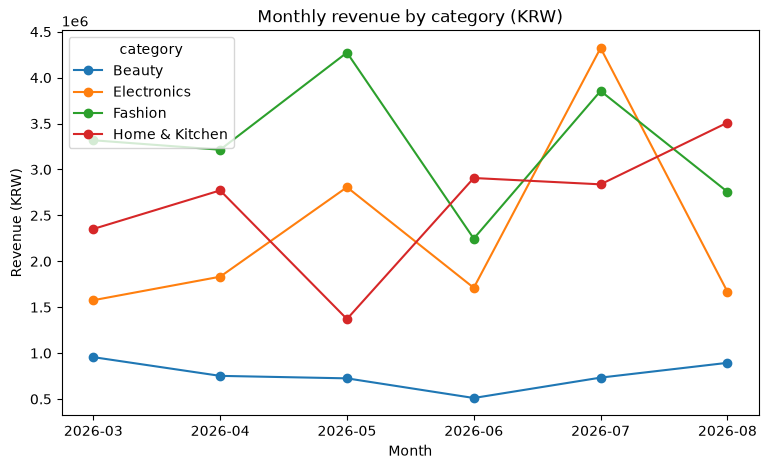

In [27]:
pivot.drop(columns="Total").plot(kind="line", marker="o", figsize=(9, 5),
title="Monthly revenue by category (KRW)")
plt.ylabel("Revenue (KRW)")
plt.xlabel("Month")
plt.show()

In [28]:
df.to_csv("orders_clean.csv", index=False)
print("Saved orders_clean.csv with", df.shape[0], "rows and", df.shape[1], "columns")

Saved orders_clean.csv with 300 rows and 13 columns
